# DEMONEXT Image Analysis

Sandbox for trying out sep and other tools for doing star finding on a DEMONEXT image for science guiding

Derived from a set of programs developed for the SDSS-V fiber positioner project to measure spots on fiber
viewing camera images.  Later expanded to more general star/object finding and inter-image coordinate
transformations.

## Star finding

Uses `sep`, a Python port of Source Extractor's algorithms to find stars. This notebook uses `sep` v.1.2.1 (https://sep.readthedocs.io/en/stable), a Python port of Source Extractor's algorithms.

### Installing `sep`

On Windows, before you install `sep` you need to install the Microsoft C++ Build Tools (https://visualstudio.microsoft.com/visual-cpp-build-tools/).  

On Linux you just follow the pip installation procedure on the `sep` readthedocs page.

This StackOverflow page shows how to do it correctly (https://stackoverflow.com/questions/40504552/how-to-install-visual-c-build-tools).

## Catalog Matching

Uses kd-tree algorithm (https://en.wikipedia.org/wiki/K-d_tree) implemented in the `scipy.spatial` package
to do fast catalog matching between the reference and target images.  K-dimensional trees are 
space-partitioning data structures used to organize data points in a k-dimensional space, useful
for searching multi-dimensional lists for nearest-neightbor matches, among other data science applications.

Source Extractor does not find objects in the same order even on very similar images, and the kd-tree has
proven to be a very fast and robust way to match XY coordinate pairs (points in a K=2 space).  We condition
the search by assuming that on two images of the same field, the median cloud of points on both should be
about the same, even if there is rotation and/or small scale changes.

## General Notes

This notebook is testing out the algorithm for DEMONEXT science guiding operations where we use the previous
image to adjust the telescope guiding with the goal of getting sub-pixel alignment of all images in a 
time series, essential for high-precision differential photometry of long time series exoplanet transits
that are the primary science driver of the DEMONEXT project.

This is an updating of the original science guiding algorithm by Steven Villanueva (CITE!), using modern
python libraries and methods from data science to replace his original python 2 code.

In [1]:
%matplotlib inline

import os
import sys
import math
import numpy as np

# Source Extractor python 

import sep

# skimage.transform for linear transforms

import skimage.transform as trans

# path support

from pathlib import Path

# pandas for ascii table input

import pandas as pd

# we'll be using a kd-tree for quick nearest-neighbor lookup

from scipy import spatial

# astropy.io fits

from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

# timing

import time

# plotting

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

# silence nuisance warnings

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)
warnings.filterwarnings('ignore',category=DeprecationWarning, append=True)

# useful function

def plotCircle(ax,xc,yc,r,color,ltype='-',alpha=1,lw=1):
    """
    plot a circle
    
    Parameters
    ----------
        ax : matplotlib axis
        xc : float
            center of the circle in X
        yc : float
            center of the circle in Y
        r : float
            radius of the circle
        color : string
            color to draw the circle (valid matplotlib color)
        
    """
    theta = np.linspace(0,2*np.pi,360,endpoint=True)
    xs = xc + r*np.cos(theta)
    ys = yc + r*np.sin(theta)
    ax.plot(xs,ys,linestyle=ltype,color=color,alpha=alpha,lw=lw,zorder=10)

# Telescope parameters

telFL = 3454.0 # mm
pixSize = 0.015 # mm
pixScale = 206265*pixSize/telFL # arcsec/pixel

## Standard plot setup

Basic setup for the various plots we'll make, this is the common configuration for each plot.

square plots, so 1:1 aspect

In [2]:
# Plot width and height in pixels

plotHeight = 4000
plotWidth = 4000

# Font and line weight defaults for axes

lwidth = 0.5
matplotlib.rcParams.update({'font.size':12})
matplotlib.rc('axes',linewidth=lwidth)

# LaTeX will be used throughout for markup of symbols

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'12'})
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'
plt.rcParams['axes.labelpad'] = '10'

# plot resolution and window

dpi = 600
wDisp = plotWidth
hDisp = plotHeight
wInches = float(wDisp)/float(dpi)
hInches = float(hDisp)/float(dpi)

## Prototype functions

### findStars()

Find stars using sep. Separate out stars by fwhm, peak brightness, and ellipticity

Selection critera:
 * `minFWHM < FWHM < maxFWHM`
 * `minPeak < peak < maxPeak`
 * `ell < maxEll`

In [11]:
def findStars(imgFile,detThresh=20,minFWHM=1.25,maxFWHM=3.0,maxEll=0.3,minPeak=5000,maxPeak=50000):
    
    # open the FITS file
    
    hdu = fits.open(imgFile,uint=False)
    data = hdu[0].data
    hdr = hdu[0].header
    hdu.close()
    
    # estimate background and subtract it
    
    bkg = sep.Background(data)
    
    print(f"sky: {bkg.globalback:.2f} +/- {bkg.globalrms:.2f}")

    imgData = data - bkg
    
    # find stars and other objects in the image
    
    objects = sep.extract(imgData,detThresh,err=bkg.globalrms)

    print(f"Found {len(objects)} objects in {imgFile}")
    
    # did we detect any objects?
    
    numObjects = len(objects)
    
    # we have objects, filter on thresholds of FWHM and peak counts
 
    x = np.array(objects['x'])
    y = np.array(objects['y'])
    a = np.array(objects['a'])
    b = np.array(objects['b'])
    flux = np.array(objects['flux'])
    peak = np.array(objects['peak'])

    # FWHM and ellipticity
    
    fwhm = np.sqrt(1.5*math.log(2)*(a*a + b*b))
    ell = 1.0 - (b/a)

    # "good star" criteria:
    #   minFWHM < fwhm < maxFWHM - is it compact and a star but bigger than a hot pixel or cre?
    #   peak < maxPeak - is it not saturated
    #   ell < ellMax - images are mostly round
    
    goodStar = np.where((fwhm>=minFWHM) & (fwhm<=maxFWHM) & (ell<=maxEll) & (peak >=minPeak) & (peak<=maxPeak))[0]

    numGood = len(goodStar)
    
    # we have good stars, return them
    
    return x[goodStar],y[goodStar]


### imExamine() - examine an image, get mean stats

Find stars using `sep` - report background, median FWHM, median ellipticity

We might be able to use a variant on this with more features to be able to make a quick
judgment about how sparse/crowded the field is, which we've seen can affect how well
we can match star catalogs during guide calibration with large offsets.  

Right now this only has the sigma detection threshold (`detThresh`) parameter, and returns only
FWHM and ellipticity as image quality indicators.  Other returns are number of stars found etc.
once we develop metrics for evaluating fields.

This could help us start the guide calibration process with better priors for the star search and 
matching criteria.


In [9]:
def imExamine(imgFile,detThresh=10):
    
    # open the FITS file
    
    hdu = fits.open(imgFile,uint=False)
    data = hdu[0].data
    hdr = hdu[0].header
    hdu.close()
    
    # estimate background and subtract it
    
    bkg = sep.Background(data)
    
    imgData = data - bkg
    
    # find stars and other objects in the image
    
    objects = sep.extract(imgData,detThresh,err=bkg.globalrms)
    
    print(f"Found {len(objects)} objects in {imgFile}")
    
    # how many objects did we detect?
    
    numObjects = len(objects)

    # compute median fwhm and ellipticity
    
    a = np.array(objects['a'])
    b = np.array(objects['b'])

    # FWHM (round equivalent)
    
    fwhm = np.sqrt(1.5*math.log(2)*(a*a + b*b))
    medFWHM = np.median(fwhm)
    
    # ellipticity
    
    ell = 1.0 - (b/a)
    medEll = np.median(ell)
        
    return medFWHM,medEll,bkg.globalback


### findShift() - compute shift from reference to target image

Read in the reference image and target image star catalogs, match the catalogs using a nearest-neighbor
algorithm based on a k-d tree (in this case, cKDTree from scipy.spatial), then compute the median
shift between the two. 

arguments:
 * `refX, refY` - float list : reference image star XY coordinates
 * `targX, targY` - float list : target image star XY coordinates
 * `dx0, dy0` - float : estimated shift to move refXY to targXY, default: no shift
 * `tol` - float : tolerance for the distance check in pixels, default: 4 pixels (~2x FWHM in good seeing)
 


In [5]:
def findShift(refX,refY,targX,targY,dx0=0,dy0=0,tol=5.0):
    
    distTol = tol # pixels from median distance
    
    # match the target and reference catalog XY using cKDTree

    targXY = np.dstack([targX,targY])[0]
    refXY = np.dstack([refX+dx0,refY+dy0])[0]

    dist,index = spatial.cKDTree(targXY).query(refXY)

    # cull the list using a common distance range (affine!)
    
    # print(f"median distance: {np.median(dist):.3f}pix, range: {np.min(dist):.3f} - {np.max(dist):.3f}")
    medDist = np.median(dist)
    minDist = medDist - distTol
    maxDist = medDist + distTol

    iGood = np.where((dist >= minDist) & (dist <= maxDist))[0]

    # compute shift to get back to the reference XY coordinates
        
    numMatch = len(iGood)
    dXoff = targX[index[iGood]] - refX[iGood]
    dYoff = targY[index[iGood]] - refY[iGood]

    # compute median shift in X and Y
    
    dX = np.median(dXoff)
    dY = np.median(dYoff)
    
    # return
    
    return dX,dY,dXoff,dYoff,numMatch

### getCoords() - get image RA/Dec

Returns an astropy.coordinates `SkyCoord()` object with the telescope RA/Dec in the FITS header
of image `fitsFile`.  

Note that MaxIm stores the **telescope** RA/Dec as `OBJCTRA` and `OBJCTDEC`.

In [6]:
def getCoords(fitsFile):
    hdr = fits.getheader(fitsFile)
    ra = hdr['OBJCTRA']
    dec = hdr['OBJCTDEC']
    return SkyCoord(ra=ra,dec=dec,unit=(u.hour,u.deg),frame='icrs')

### imgOffset() - compute RA/Dec offset in pixels

Given RA/Dec coordinates for a reference and target image, estimates the pixel offset between the
images (put move target corodinates to the reference coordinates) in the tangent plane ($\xi$,$\eta$) coordinates).

`rot` is the rough orientation of the image pixel coordinates relative to RA/Dec.  I've written this
generally, maybe a better way is a rotation angle and do the transform in place??  TBD

arguments:
 * `refCoords` - `SkyCoord` object: reference image RA/Dec
 * `targCoords` - `SkyCoord` object: target image RA/Dec
 * `orient` - string: rough image orientation, one of {None,"cw90","ccw90","180"}

In [7]:
def imgOffset(refCoords,targCoords,rot=None):
    telFL = 3454.0 # mm
    pixSize = 0.015 # mm
    pixScale = 206265*pixSize/telFL # arcsec/pixel

    # RA/Dec offset on the tangent plane
    
    dra, ddec = targCoords.spherical_offsets_to(refCoords)

    xiPix = dra.to(u.arcsec).value/pixScale   # pixels in xi (RA)
    etaPix = ddec.to(u.arcsec).value/pixScale # pixels in eta (DEC)
    
    distPix = np.sqrt(xiPix*xiPix + etaPix*etaPix)
    
    # pixel offset
    
    if not rot:
        return -xiPix, etaPix
    elif rot.lower() == "cw90":
        return -etaPix, xiPix
    elif rot.lower() == "ccw90":
        return etaPix, -xiPix
    elif rot.lower() == "180":
        return xiPix, -etaPix


## Image analysis

Read in a raw FITS file and process using Source Extractor (`sep`)

### Refererence image

Create the `refX,refY` lists with the reference star XY positions on the reference image.

Found 2244 objects in Data/n20190621/n20190621.GuideCal.i.0056.fits
Image Stats: med FWHM: 1.73 pix, med Ell: 0.099, sky: 2352.73 adu
sky: 2352.73 +/- 10.69
Found 1146 objects in Data/n20190621/n20190621.GuideCal.i.0056.fits
Done: Found 42 stars on the reference image, exectime 0.265 seconds


[]

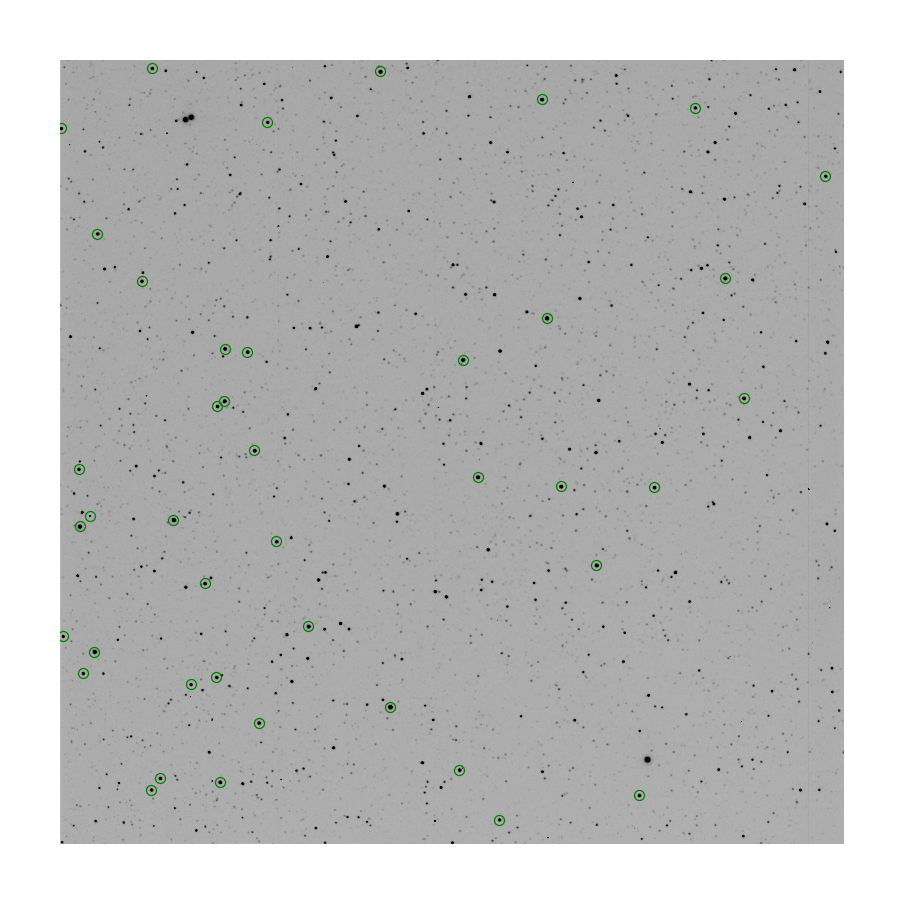

In [12]:
dataDir = "./Data/n20190621"

detThresh = 10
minPeak = 3000
maxFWHM = 4.0
maxEll = 0.3

# reference image name

rootName = "n20190621.GuideCal.i.0056"
#rootName = "n20190620.KS14C005909.i.0001"

refFile = f"{rootName}.fits"

# full path version

fitsFile = str(Path(dataDir) / f"{refFile}")

# get the telescope RA/Dec of the reference image 

refCoords = getCoords(fitsFile)

# image examination...

t0 = time.time()
medFW, medEll, bkg = imExamine(fitsFile,detThresh=5)
print(f"Image Stats: med FWHM: {medFW:.2f} pix, med Ell: {medEll:.3f}, sky: {bkg:.2f} adu")

if maxFWHM < 2*medFW:
    print(f"increasing max FWHM from {maxFWHM:.2f} to {2*medFW:.2f}")
    maxFWHM = 2*medFW

refX,refY = findStars(fitsFile,detThresh=detThresh,minPeak=minPeak,maxFWHM=maxFWHM,maxEll=maxEll)
dt = time.time() - t0

numRef = len(refX)
print(f"Done: Found {numRef} stars on the reference image, exectime {dt:.3f} seconds")

fig,ax = plt.subplots(figsize=(wInches/4,hInches/4),dpi=dpi)

hdu = fits.open(fitsFile,uint=False)    
img = hdu[0].data
hdr = hdu[0].header
naxis1 = hdr['naxis1']
naxis2 = hdr['naxis2']
hdu.close()

medImg = np.median(img)
stdImg = np.std(img)

zMin = medImg - stdImg
zMax = medImg + 2*stdImg

plt.imshow(img,cmap=plt.cm.binary,extent=[0,naxis1,naxis2,0],vmin=zMin,vmax=zMax)
plt.axis('off')

# note -0.5 pixels for plot because of differences in sep vs. matplotlib pixel coords (sep center, mpl origin)

plt.plot(refX-0.5,refY-0.5,'o',ms=1.2,mec='green',mew=0.15,mfc="None")

plt.tight_layout()
plt.plot()


### Measure stars on the target image

Use the same parameters and measure `targX,targY` for the target image.

Plot stars on the image as circles, blue crosses are the reference star positions.

dx0=1.0351 pix dy0=-128.9027 pix  (pixScale=0.896 arcsec/pix)
Done: Found 37 stars on the target image, exectime 0.181 seconds


[]

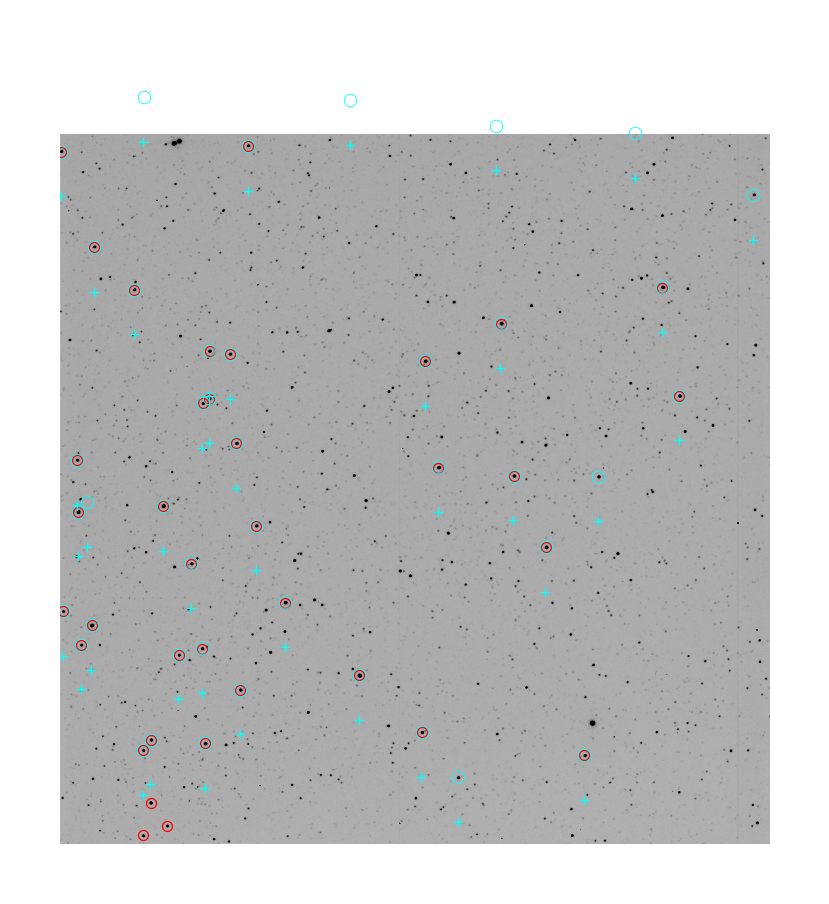

In [9]:
# reference image name

rootName = "n20190621.GuideCal.i.0057"
#rootName = "n20190620.KS14C005909.i.0372"

targFile = f"{rootName}.fits"

# full path version

fitsFile = str(Path(dataDir) / f"{targFile}")
  
# get the image RA/Dec and compute the estimated relative offset in pixels

targCoords = getCoords(fitsFile)
dx0, dy0 = imgOffset(refCoords,targCoords,rot="cw90")
print(f"dx0={dx0:.4f} pix dy0={dy0:.4f} pix  (pixScale={pixScale:.3f} arcsec/pix)")

# find stars in the target image

t0 = time.time()
targX,targY = findStars(fitsFile,detThresh=detThresh,minPeak=minPeak,maxFWHM=maxFWHM,maxEll=maxEll)
dt = time.time() - t0
numTarg = len(targX)
print(f"Done: Found {numTarg} stars on the target image, exectime {dt:.3f} seconds")

# show the image and the stars found

fig,ax = plt.subplots(figsize=(wInches/4,hInches/4),dpi=dpi)

hdu = fits.open(fitsFile,uint=False)    
img = hdu[0].data
hdr = hdu[0].header
naxis1 = hdr['naxis1']
naxis2 = hdr['naxis2']
hdu.close()

medImg = np.median(img)
stdImg = np.std(img)

zMin = medImg - stdImg
zMax = medImg + 2*stdImg

plt.imshow(img,cmap=plt.cm.binary,extent=[0,naxis1,naxis2,0],vmin=zMin,vmax=zMax)
plt.axis('off')

# note -0.5 pixels for plot because of differences in sep vs. matplotlib pixel coords (sep center, mpl origin)

plt.plot(targX-0.5,targY-0.5,'o',ms=1.2,mec='red',mew=0.15,mfc="None",zorder=9)

# plot reference stars as crosses

plt.plot(refX-0.5,refY-0.5,"+",ms=1.2,mec='cyan',mew=0.15,mfc="None",zorder=10)
plt.plot(refX-0.5+dx0,refY-0.5+dy0,"o",ms=1.5,mec='cyan',mew=0.1,mfc="None",zorder=10)

plt.tight_layout()
plt.plot()


## Compute the relative shift


In [ ]:
t0 = time.time()
dX,dY,dXoff,dYoff,nm = findShift(refX,refY,targX,targY,dx0=dx0,dy0=dy0)
dt = time.time() - t0

print(f"{nm} matches: median dX,dY = {dX:.3f},{dY:.3f}")
# geometric shift

dXavg = np.mean(dXoff)
dXsig = np.std(dXoff)
dYavg = np.mean(dYoff)
dYsig = np.std(dYoff)

print(f"mean dX,dY = {dXavg:.3f} +/- {dXsig:.3f}, {dYavg:.3f} +/- {dYsig:.3f} exec time {dt:.4f} sec")

## Guider Calibration

This reproduces the original 2016 science guider calibration procedure, less data acquisition.  We're running
with actual guide calibration images taken from the original system to test.

refImage 

In [ ]:
# guider calibration 

mx = 10  # guider move in x - units of seconds
my = 10  # guider move in y - units of seconds

offsetSeq = [(mx,0),(-mx,0),(0,my),(0,-my)]

# guide calibration images

rootName = "n20190621.GuideCal.i"
refImage = 61
calImages = np.arange(refImage+1,refImage+5)

# search parameters

detThresh = 10
minPeak = 5000
maxEll = 0.3
maxFWHM = 4.0

# timer

t0 = time.time()

# zero (reference) image

refFile = str(Path(dataDir) / f"{rootName}.{refImage:04d}.fits")

# reference image RA/Dec coords

refCoords = getCoords(refFile)

print(f"\n{refFile}: {refCoords.to_string('hmsdms',sep=':')}")
cosDec = np.cos(np.radians(refCoords.dec.value))

refX,refY = findStars(refFile,detThresh=detThresh,minPeak=minPeak,maxFWHM=maxFWHM,maxEll=maxEll)
print(f"  Num found: {len(refX)}")

# display the reference image and mark the stars

fig,ax = plt.subplots(figsize=(wInches/4,hInches/4),dpi=dpi)

hdu = fits.open(refFile,uint=False)    
img = hdu[0].data
hdr = hdu[0].header
naxis1 = hdr['naxis1']
naxis2 = hdr['naxis2']
hdu.close()

medImg = np.median(img)
stdImg = np.std(img)

zMin = medImg - stdImg
zMax = medImg + 2*stdImg

plt.imshow(img,cmap=plt.cm.binary,extent=[0,naxis1,naxis2,0],vmin=zMin,vmax=zMax)
plt.axis('off')

# note -0.5 pixels for plot because of differences in sep vs. matplotlib pixel coords (sep center, mpl origin)

plt.plot(refX-0.5,refY-0.5,'o',ms=1.2,mec='green',mew=0.15,mfc="None")

# calibration images

dX = []
dY = []
colors = ['red','cyan','orange','magenta']
for i in range(len(calImages)):
    calFile = str(Path(dataDir) / f"{rootName}.{calImages[i]:04d}.fits")

    print(f"\n{calFile}:")

    calCoords = getCoords(calFile)

    # find stars
    
    calX,calY = findStars(calFile,detThresh=detThresh,minPeak=minPeak,maxFWHM=maxFWHM,maxEll=maxEll)
    
    # plt.plot(calX-0.5,calY-0.5,'+',ms=1.2,mec='cyan',mew=0.15,mfc="None")
    plt.plot(calX-0.5,calY-0.5,'+',ms=1.2,mec=colors[i],mew=0.15,mfc="None")

    if i == 0:
        delX,delY,dXoff,dYoff,nm = findShift(refX,refY,calX,calY,dx0=dx0,dy0=dy0)
        dx0, dy0 = imgOffset(refCoords,calCoords,rot="cw90")
    else:
        delX,delY,dXoff,dYoff,nm = findShift(lastX,lastY,calX,calY)
        dx0, dy0 = imgOffset(lastCoords,calCoords,rot="cw90")
        
    print(f"dx0={dx0:.4f} pix dy0={dy0:.4f} pix  (pixScale={pixScale:.3f} arcsec/pix)")

    lastCoords = calCoords
    lastX = calX
    lastY = calY

    dX.append(delX)
    dY.append(delY)
    print(f"found {nm} matches: dX={delX:.3f} dY={delY:.3f}")
    
# summary

print("\nSummary shifts:")
for i in range(len(dX)):
    print(f"  dx{i+1},dy{i+1}: {dX[i]:8.3f} {dY[i]:8.3f}")

# compute guider calibration parameters

alpha1 = 0.5*(dX[0]-dX[1])
delta1 = 0.5*(dY[0]-dY[1])
dist1 = np.sqrt(alpha1*alpha1 + delta1*delta1)
theta1 = np.arctan2(delta1,alpha1)
print(f"\nalpha1={alpha1:8.3f} delta1={delta1:.3f} dist1={dist1:.3f} pix theta1={np.degrees(theta1):.4f}")

alpha2 = 0.5*(dX[2]-dX[3])
delta2 = 0.5*(dY[2]-dY[3])
dist2 = np.sqrt(alpha2*alpha2 + delta2*delta2)
theta2 = 0.5*np.pi + np.arctan2(delta2,alpha2)
print(f"alpha2={alpha2:.3f} delta2={delta2:.3f} dist2={dist2:.3f} pix theta2={np.degrees(theta2):.4f}")

mytheta = 0.5*(theta1+theta2)
myb = -mx/dist1 # sec/pixel
mya = my/dist2 # sec/pixel

if alpha1 == 0:
    phi1 = np.arctan(np.inf)
    if delta1 < 0:
        phi1 = np.arctan(-np.inf)
else:
    phi1 = np.arctan(-1.*delta1/alpha1)

theta = -1.*phi
print(f"\n  theta={np.degrees(theta):.4f} deg")

b = (alpha1*my*np.cos(theta) - alpha2*mx*np.sin(theta)) / (delta1*alpha2*(np.sin(theta)**2.) + delta2*alpha1*(np.cos(theta)**2.))

a = (mx + b*delta1*np.cos(theta)) / (alpha1*np.cos(theta))

print(f"\nSV Guider Coefficients: a = {a:.4f} ; b = {b:.4f} ; angle = {np.degrees(theta):.4f} degrees")

print(f"\nMy Guider Coefficients: a = {mya:.4f} ; b = {myb:.4f} ; angle = {np.degrees(mytheta):.4f} degrees")
print(f"                   cosDec corrected: b = {cosDec*myb:.4f}")

for i in range(len(dX)):
    dist = np.sqrt(dX[i]*dX[i] + dY[i]*dY[i])
    
    if abs(dX[i]) > abs(dY[i]):
        if dX[i] < 0:
            th = np.arctan2(dY[i],dX[i])
        else:
            th = np.arctan2(dY[i],dX[i]) - np.pi
        print(f"  move {i+1}: a={my/dist:8.4f} sec/pix  theta={90+np.degrees(th):.4f} deg")
    else:
        if dY[i] < 0:
            th = np.arctan2(dY[i],dX[i])
        else:
            th = np.arctan2(dY[i],dX[i]) - np.pi
        print(f"  move {i+1}: b={-mx/dist:8.4f} sec/pix  theta={np.degrees(th):.4f} deg")


print(f"\nApplication:")
for i in range(len(dX)):
    tmx = myb*dY[i]*np.sin(mytheta) + mya*dX[i]*np.cos(mytheta)
    tmy = myb*dY[i]*np.cos(mytheta) - mya*dX[i]*np.sin(mytheta)
    dmx = tmx + offsetSeq[i][0]
    dmy = tmy + offsetSeq[i][1]
    print(f"  move {i+1}: {tmx:7.3f},{tmy:7.3f}; actual: {-offsetSeq[i][0]:5.1f},{-offsetSeq[i][1]:5.1f}; error: {dmx:6.3f},{dmy:6.3f}")

dt = time.time() - t0
print(f"\nexecution time: {dt:.3f} sec")